In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv('Data/Final_Data.csv')

In [7]:
data = data.drop(columns=["SiteKey"])
data.shape

(1599443, 36)

In [ ]:
X_now = data.drop(columns=[
    "CapacityFactor",
    "Target_15min","Target_1h","Target_3h",
    "Residual_15min","Residual_1h","Residual_3h",
    "Residual_now",
    "SolarGeneration"
])

y_now = data["Residual_now"]
true_now = data["CapacityFactor"]

n_splits = 5
split_size = int(len(X_now) / (n_splits + 1))
max_train_size = 1599443

mae_model_now = 0
mae_naive_now = 0
r2_now = 0

for i in range(n_splits):
    train_end = split_size * (i+1)
    test_end = split_size * (i+2)
    train_start = max(0, train_end - max_train_size)

    X_train = X_now.iloc[train_start:train_end]
    X_test = X_now.iloc[train_end:test_end]

    y_train = y_now.iloc[train_start:train_end]
    true_test = true_now.iloc[train_end:test_end]

    lag_test = X_test["Lag_1"].values

    model = LGBMRegressor(
        n_estimators=400,
        learning_rate=0.1,
        max_depth=18,
        num_leaves=256,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(X_train, y_train)
    residual_pred = model.predict(X_test)

    pred = lag_test + residual_pred

    mae_model_now += mean_absolute_error(true_test, pred)
    mae_naive_now += mean_absolute_error(true_test, lag_test)
    r2_now += r2_score(true_test, pred)

mae_model_now /= n_splits
mae_naive_now /= n_splits
r2_now /= n_splits

print("\nLIGHTGBM CURRENT PREDICTION")
print("Naive MAE:", mae_naive_now)
print("Model MAE:", mae_model_now)
print("R2:", r2_now)



LIGHTGBM CURRENT PREDICTION
Naive MAE: 0.00891871835001148
Model MAE: 0.00585100819067296
R2: 0.9645821825222234


In [9]:
importance_now = pd.DataFrame({
    "Feature": X_now.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== CURRENT MODEL FEATURE IMPORTANCE ===")
print(importance_now.head(20))


=== CURRENT MODEL FEATURE IMPORTANCE ===
                Feature  Importance
15          Temp_change        6259
2   DewPointTemperature        5495
13       Humidity_solar        5192
16      Humidity_change        5097
11       SolarPotential        4931
26           CloudTrend        4723
9               Day_sin        4666
21               Ramp_1        4596
0   ApparentTemperature        4581
3      RelativeHumidity        4411
22               Ramp_2        4249
12           Temp_solar        4048
10              Day_cos        3903
1        AirTemperature        3891
18                Lag_1        3845
14           Wind_solar        3677
17          Wind_change        3464
23         RollingStd_4        3415
5           WindDir_sin        3257
4             WindSpeed        3040


In [10]:
X = data.drop(columns=[
    "CapacityFactor",
    "Target_15min","Target_1h","Target_3h",
    "Residual_15min","Residual_1h","Residual_3h",
    "SolarGeneration"
])

Y = data[["Residual_15min", "Residual_1h", "Residual_3h"]]
Y_true = data[["Target_15min", "Target_1h", "Target_3h"]]

n_splits = 5
split_size = int(len(X) / (n_splits + 1))
max_train_size = 1599443

mae_model = np.zeros(3)
mae_naive = np.zeros(3)
r2_scores = np.zeros(3)

for i in range(n_splits):
    train_end = split_size * (i+1)
    test_end = split_size * (i+2)
    train_start = max(0, train_end - max_train_size)

    X_train = X.iloc[train_start:train_end]
    X_test = X.iloc[train_end:test_end]

    Y_train = Y.iloc[train_start:train_end]
    true_test = Y_true.iloc[train_end:test_end]

    lag_test_15 = X_test["Lag_1"].values
    lag_test_1h = X_test["Lag_2"].values
    lag_test_3h = X_test["Lag_3"].values
    lag_tests = [lag_test_15, lag_test_1h, lag_test_3h]

    model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.1,
            max_depth=18,
            num_leaves=256,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        )
    )

    model.fit(X_train, Y_train)
    residual_pred = model.predict(X_test)

    pred = np.zeros_like(residual_pred)

    for h in range(3):
        pred[:, h] = lag_tests[h] + residual_pred[:, h]

    for h in range(3):
        mae_model[h] += mean_absolute_error(true_test.iloc[:, h], pred[:, h])
        mae_naive[h] += mean_absolute_error(true_test.iloc[:, h], lag_tests[h])
        r2_scores[h] += r2_score(true_test.iloc[:, h], pred[:, h])

mae_model /= n_splits
mae_naive /= n_splits
r2_scores /= n_splits

horizons = ["15 min","1 hour","3 hour"]

for i, h in enumerate(horizons):
    print("\nLIGHTGBM Horizon:", h)
    print("Naive MAE:", mae_naive[i])
    print("Model MAE:", mae_model[i])
    print("R2:", r2_scores[i])


LIGHTGBM Horizon: 15 min
Naive MAE: 0.013283456971665514
Model MAE: 0.006372392134088731
R2: 0.9626190645022948

LIGHTGBM Horizon: 1 hour
Naive MAE: 0.025374984928098875
Model MAE: 0.015290203800651206
R2: 0.8401513930990223

LIGHTGBM Horizon: 3 hour
Naive MAE: 0.04857314903658821
Model MAE: 0.0246017467017737
R2: 0.6494493130499417


In [11]:
horizons = ["15 min","1 hour","3 hour"]

for i, h in enumerate(horizons):
    lgb_model = model.estimators_[i]
    importance = lgb_model.booster_.feature_importance(importance_type='gain')
    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)
    
    print(f"\n=== TOP FEATURES: {h} ===")
    print(feat_imp.head(30))


=== TOP FEATURES: 15 min ===
                Feature   Importance
27         Residual_now  3026.100529
18                Lag_1   476.151716
15          Temp_change   458.076806
26           CloudTrend   375.238325
25      CloudinessIndex   355.035177
21               Ramp_1   244.930744
11       SolarPotential   243.570449
23         RollingStd_4   202.007455
7              Hour_sin   198.939018
13       Humidity_solar   191.284689
16      Humidity_change   154.353918
2   DewPointTemperature   151.401956
12           Temp_solar   142.044040
9               Day_sin   142.017586
0   ApparentTemperature   139.147713
10              Day_cos   138.543331
1        AirTemperature   130.882816
22               Ramp_2   128.932146
14           Wind_solar   125.469662
3      RelativeHumidity   124.264364
20                Lag_3   120.780747
17          Wind_change    93.042008
6           WindDir_cos    87.724840
4             WindSpeed    82.581937
5           WindDir_sin    82.153331
19      

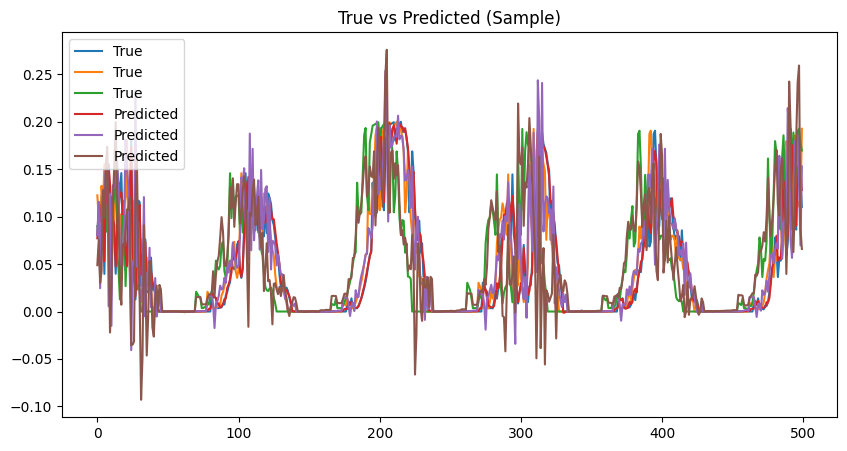

In [12]:
plt.figure(figsize=(10,5))
plt.plot(true_test.values[:500], label="True")
plt.plot(pred[:500], label="Predicted")
plt.legend()
plt.title("True vs Predicted (Sample)")
plt.show()

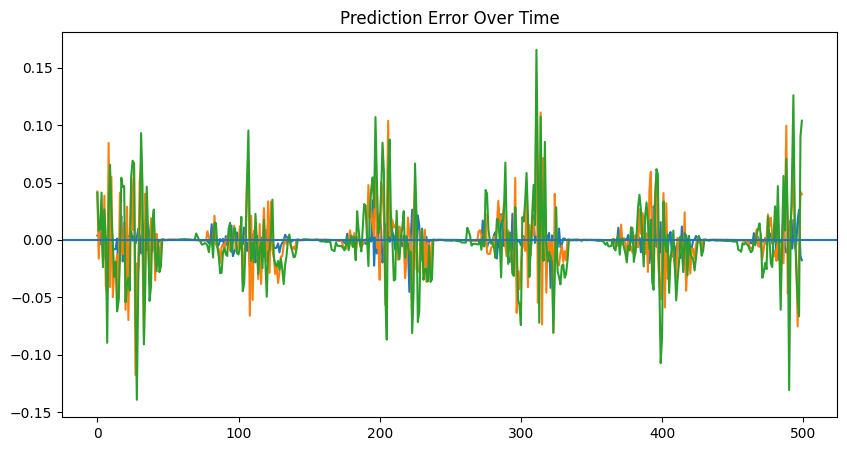

In [13]:
errors = true_test.values - pred

plt.figure(figsize=(10,5))
plt.plot(errors[:500])
plt.title("Prediction Error Over Time")
plt.axhline(0)
plt.show()